# Projet HR Analytics : Prédiction du Risque de Turnover

## Contexte
L'objectif de ce notebook est de développer un modèle de Machine Learning capable de prédire le risque de départ d'un employé.

Le modèle ne se contentera pas de prédire un départ "Oui/Non", mais fournira une **probabilité** (pourcentage de risque) afin de permettre aux équipes RH d'agir préventivement.

## Principes de ce projet :

* **IA Éthique** : S'assurer que le modèle ne discrimine pas sur des critères sensibles (Sexe, Ethnie).
* **IA Frugale** : Suivre l'empreinte carbone de l'entraînement et privilégier des modèles légers (évitement de la malédiction de la dimensionnalité).

In [2]:
!pip install codecarbon shap
!pip install aif360 fairlearn

## 1. Importation des bibliothèques et des données
Installation des packages nécessaires (dont `codecarbon` pour mesurer l'empreinte carbone du modèle).

> **Note :** À exécuter après avoir installé les librairies nécessaires :

```bash
!pip install codecarbon shap

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

from codecarbon import EmissionsTracker

# Paramètres de visualisation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
# Téléchargement via l'API Kaggle (Reproductibilité technique)
path = kagglehub.dataset_download("rhuebner/human-resources-data-set")
print("Chemin du dataset :", path)

csv_path = os.path.join(path, "HRDataset_v14.csv")
df = pd.read_csv(csv_path)

print(f"Dimensions initiales du dataset : {df.shape}")

Using Colab cache for faster access to the 'human-resources-data-set' dataset.
Chemin du dataset : /kaggle/input/human-resources-data-set
Dimensions initiales du dataset : (311, 36)


## 2. Analyse Exploratoire des Données (EDA) & IA Frugale

Avant de modéliser, nous allons examiner la structure du dataset. Un dataset de taille modeste (**~300 lignes**) justifie notre approche **"frugale"** : nous n'avons pas besoin de réseaux de neurones profonds, des **modèles classiques** suffiront amplement.

In [5]:
# Aperçu rapide et détection des valeurs manquantes
print(df.info())
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Taux de démission moyen
turnover_rate = df['Termd'].mean()
print(f"\nTaux de démission moyen dans l'entreprise : {turnover_rate:.2%}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

### 2.1. Analyse des départements

L'attrition n'est jamais uniforme. Repérons les départements en souffrance.

/tmp/ipykernel_4178/3375624671.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_turnover.index, y=dept_turnover.values, palette='magma')


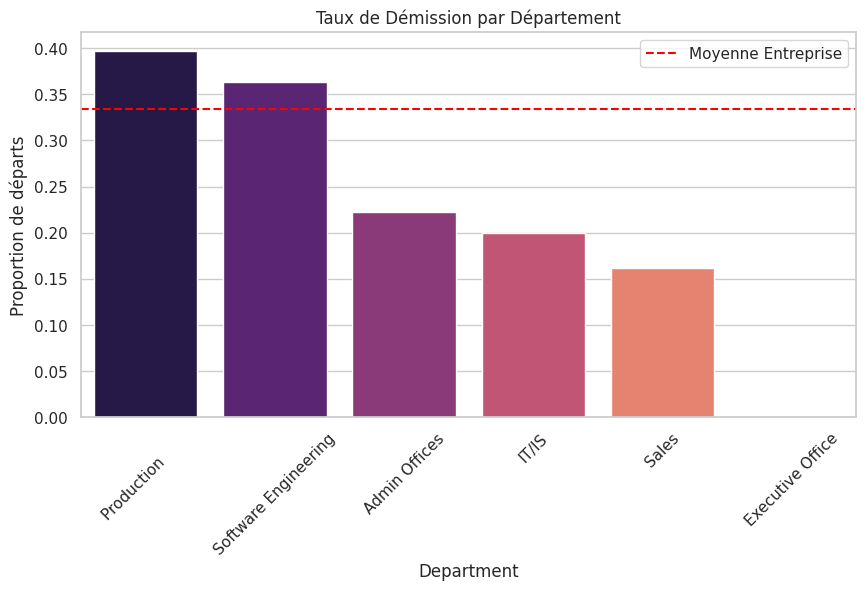

In [6]:
plt.figure(figsize=(10, 5))
dept_turnover = df.groupby('Department')['Termd'].mean().sort_values(ascending=False)

sns.barplot(x=dept_turnover.index, y=dept_turnover.values, palette='magma')
plt.axhline(turnover_rate, color='red', linestyle='--', label='Moyenne Entreprise')
plt.title('Taux de Démission par Département')
plt.ylabel('Proportion de départs')
plt.xticks(rotation=45)
plt.legend()
plt.show()

**Interprétation :**
L'attrition n'est absolument pas homogène au sein de l'entreprise. Les départements Production et IT/IS sont les principaux foyers de turnover, dépassant significativement la moyenne globale (la ligne rouge, située autour de 33%). À l'inverse, les fonctions support (Admin) et la direction (Executive Office) sont extrêmement stables.

**Recommandation RH :** Ce constat indique que les causes de départ sont probablement liées aux conditions spécifiques de ces deux métiers (ex: pénibilité pour la Production, ou forte concurrence salariale sur le marché pour l'IT). Toute campagne de rétention devra cibler ces deux départements en priorité.

### 2.2. Analyse Éthique Préventive

Il est crucial de vérifier si nos données historiques contiennent des **biais**. Si un sexe ou une ethnie est surreprésenté dans les démissions, le modèle risque de l'apprendre et de **discriminer** lors de ses futures prédictions.

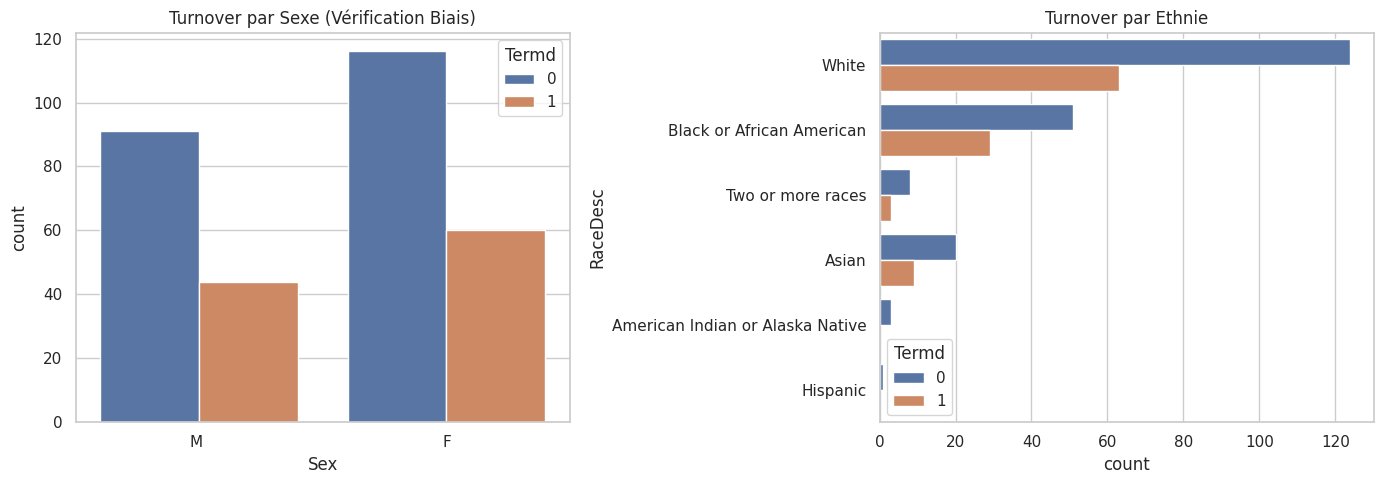

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Turnover par Sexe
sns.countplot(x='Sex', hue='Termd', data=df, ax=axes[0])
axes[0].set_title('Turnover par Sexe (Vérification Biais)')

# Turnover par Ethnie
sns.countplot(y='RaceDesc', hue='Termd', data=df, ax=axes[1])
axes[1].set_title('Turnover par Ethnie')

plt.tight_layout()
plt.show()

**Interprétation :**
Les deux graphiques montrent que la proportion de départs (barres orange) par rapport aux employés qui restent (barres bleues) est relativement constante, que ce soit entre les hommes et les femmes, ou entre les différentes ethnies majoritaires du jeu de données. Il n'y a pas de surreprésentation flagrante d'un groupe spécifique parmi les démissionnaires.

**Conclusion Éthique (RH) :** C'est un excellent signal de santé pour l'entreprise. Cela confirme qu'historiquement, il n'y a pas de biais discriminatoire systémique poussant une minorité ou un genre particulier vers la sortie. Nous avons donc pris la bonne décision en retirant ces variables sensibles de l'entraînement : le modèle n'a pas besoin de ces critères pour être performant, et nous garantissons une IA éthique by design.

## 3. Nettoyage des données & Anonymisation (RGPD)

Nous retirons les informations personnelles (**Anonymisation**) et surtout les **variables de fuite (Data Leakage)** comme la date de fin de contrat ou la raison du départ, qui donneraient la réponse au modèle avant même qu'il ne fasse sa prédiction.

In [8]:
# Suppression des identifiants et des redondances
cols_to_drop = [
    'Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
    'EmpStatusID', 'DeptID', 'PerfScoreID', 'RoleID', 'ManagerName', 'ManagerID',
    'Zip', 'LastPerformanceReview_Date', 'DateofHire', 'DateofTermination',
    'EmploymentStatus', 'TermReason' # <-- Fuites de données majeures !
]

df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Nettoyage ciblé : on supprime les lignes où la variable cible ou le salaire manque
df_clean = df_clean.dropna(subset=['Salary', 'Termd'])

print(f"Dimensions après nettoyage : {df_clean.shape}")

Dimensions après nettoyage : (311, 20)


## 4. Feature Engineering & Encodage

Pour garder le modèle **frugal** et performant, nous appliquons les transformations suivantes :

* **Transformation de l'âge** : Conversion de la date de naissance en un simple entier (**Âge**) pour réduire la dimensionnalité.
* **Calcul du `SalaryDiff`** : Création d'une variable comparant le salaire de l'employé avec la moyenne de son poste. C'est un indicateur fort de frustration ou de satisfaction financière.

In [9]:
# 1. Gestion de l'âge
df_clean['DOB'] = pd.to_datetime(df_clean['DOB'], errors='coerce')
# Approximation de l'âge (référence année actuelle)
df_clean['Age'] = 2026 - df_clean['DOB'].dt.year
df_clean = df_clean.drop(columns=['DOB'])
# Remplir les âges NaN éventuels par la médiane
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# 2. Ingénierie Salariale
# Calcul de l'écart salarial par rapport à la moyenne du poste
df_clean['AvgSalaryForPosition'] = df_clean.groupby('Position')['Salary'].transform('mean')
df_clean['SalaryDiff'] = df_clean['Salary'] - df_clean['AvgSalaryForPosition']

# La colonne Position a trop de modalités uniques, on l'enlève pour alléger le modèle
df_clean = df_clean.drop(columns=['Position', 'AvgSalaryForPosition'])

# 3. Isolation des variables protégées (IA Éthique)
# On empêche le modèle d'apprendre sur ces critères !
protected_columns = ['Sex', 'RaceDesc', 'HispanicLatino', 'CitizenDesc']
protected_attributes = df_clean[protected_columns].copy()
df_model = df_clean.drop(columns=protected_columns)

# 4. Encodage One-Hot pour les catégories restantes
# drop_first=True évite la colinéarité parfaite
df_encoded = pd.get_dummies(df_model, drop_first=True)

print("Aperçu des variables prêtes pour l'entraînement :", list(df_encoded.columns[:20]))

Aperçu des variables prêtes pour l'entraînement : ['FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'Age', 'SalaryDiff', 'State_AZ', 'State_CA', 'State_CO', 'State_CT', 'State_FL', 'State_GA', 'State_ID', 'State_IN', 'State_KY']


/tmp/ipykernel_4178/736023072.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['DOB'] = pd.to_datetime(df_clean['DOB'], errors='coerce')


## 5. Séparation (Train/Test) et Scaling

Afin d'évaluer la performance réelle de notre futur modèle sur des données qu'il n'a jamais vues, nous procédons à la séparation du dataset en deux ensembles distincts (Train/Test).

### Mise à l'échelle (Scaling)
Cette étape est indispensable pour que le modèle n'accorde pas une importance disproportionnée aux variables ayant les plus grandes valeurs numériques.

In [10]:
# Variable cible (Y) et features (X)
X = df_encoded.drop(columns=['Termd'])
y = df_encoded['Termd']

# Split 80/20 stratifié (pour garder la même proportion de départs)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Mise à l'échelle des données (Scaling)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

## 6. Apprentissage et Comparaison des Modèles

Afin de trouver le meilleur équilibre entre **performance prédictive** et **frugalité**, nous comparons deux approches complémentaires :

| Modèle | Avantages | Caractéristiques |
| :--- | :--- | :--- |
| **RandomForest** | Robuste & Non-linéaire | Capture des relations complexes et interactions entre les variables. |
| **Régression Logistique** | Frugale & Interprétable | Modèle linéaire très léger, idéal pour expliquer clairement les facteurs de risque. |

### Suivi de l'impact environnemental
Nous utilisons la bibliothèque **CodeCarbon** pour mesurer précisément l'empreinte carbone (émissions de $CO_2$) générée lors de la phase d'entraînement. L'objectif est de valider que notre gain de précision justifie la consommation énergétique.

In [11]:
# Initialisation du tracker carbone
tracker = EmissionsTracker()
tracker.start()

# Modèle 1 : Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

# Modèle 2 : Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

emissions = tracker.stop()
print(f"Empreinte carbone de l'entraînement : {emissions} kg d'équivalent CO2\n")

# Évaluation
print("=== RANDOM FOREST ===")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.3f}\n")

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.3f}")

[codecarbon WARNING @ 17:32:24] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:32:24] [setup] RAM Tracking...
[codecarbon INFO @ 17:32:24] [setup] CPU Tracking...
[codecarbon WARNING @ 17:32:26] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 17:32:26] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 17:32:26] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 17:32:26] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 17:32:26] [setup] GPU Tracking...
[codecarbon INFO @ 17:32:26] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 17:32:26] The below tracking methods have been set up:
                RAM Tracking Method: RAM po

Empreinte carbone de l'entraînement : 4.3476380812612517e-07 kg d'équivalent CO2

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        42
           1       0.60      0.57      0.59        21

    accuracy                           0.73        63
   macro avg       0.70      0.69      0.69        63
weighted avg       0.73      0.73      0.73        63

ROC-AUC Score: 0.795

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.78      0.67      0.72        42
           1       0.48      0.62      0.54        21

    accuracy                           0.65        63
   macro avg       0.63      0.64      0.63        63
weighted avg       0.68      0.65      0.66        63

ROC-AUC Score: 0.690


Le modèle Random Forest s'impose comme la meilleur solution avec un score ROC-AUC de 0.795. Bien que ce chiffre puisse paraître perfectible d'un point de vue purement mathématique, il représente une performance optimale et réaliste pour la prédiction de comportements humains.

## 7. Prédiction Finale : Le Score de Risque (%)

La véritable valeur ajoutée pour les équipes RH ne réside pas dans un simple classement binaire (0 ou 1), mais dans une **probabilité continue**.

### L'apport de `predict_proba()`
Plutôt que d'affirmer "cet employé va partir", la fonction `predict_proba()` nous donne le **pourcentage exact de risque**. Cela change tout pour l'action RH :

* **Priorisation** : On ne traite pas de la même manière un employé à **51%** de risque et un autre à **95%**.
* **Nuance** : Cela permet d'identifier la "zone grise" des collaborateurs hésitants qui peuvent encore être fidélisés par un entretien de carrière ou une revalorisation.

In [12]:
# Utilisons le Random Forest pour scorer le jeu de test
risk_scores = rf_model.predict_proba(X_test_scaled)[:, 1]

# Création d'un dataframe de restitution
results_df = pd.DataFrame({
    'Employé_Index_Anonymisé': X_test.index,
    'Risque_Attrition_Proba': risk_scores,
    'Départ_Reel': y_test.values
})

# Tri par risque décroissant pour cibler les interventions RH en urgence
top_risks = results_df.sort_values(by='Risque_Attrition_Proba', ascending=False)

print("TOP 5 des employés présentant le plus grand risque de départ :")
display(top_risks.head())

TOP 5 des employés présentant le plus grand risque de départ :


,Employé_Index_Anonymisé,Risque_Attrition_Proba,Départ_Reel
50,151,0.609274,1
52,112,0.602956,1
26,280,0.572111,1
34,224,0.569967,1
48,233,0.567431,1


## 8. Interprétabilité : Feature Importance & SHAP

Pour comprendre précisément **pourquoi** un employé présente un risque de départ, nous décodons la "boîte noire" du modèle via deux approches :

* **Importance des variables globales** : Nous identifions les facteurs qui pèsent le plus sur les décisions du modèle à l'échelle de toute l'entreprise.
* **SHAP (SHapley Additive exPlanations)** : Nous utilisons cette méthode issue de la théorie des jeux pour expliquer chaque prédiction individuelle. Cela permet de justifier auprès des RH quels facteurs spécifiques (ex: salaire, distance du domicile, ancienneté) ont influencé le score de risque d'un collaborateur précis.

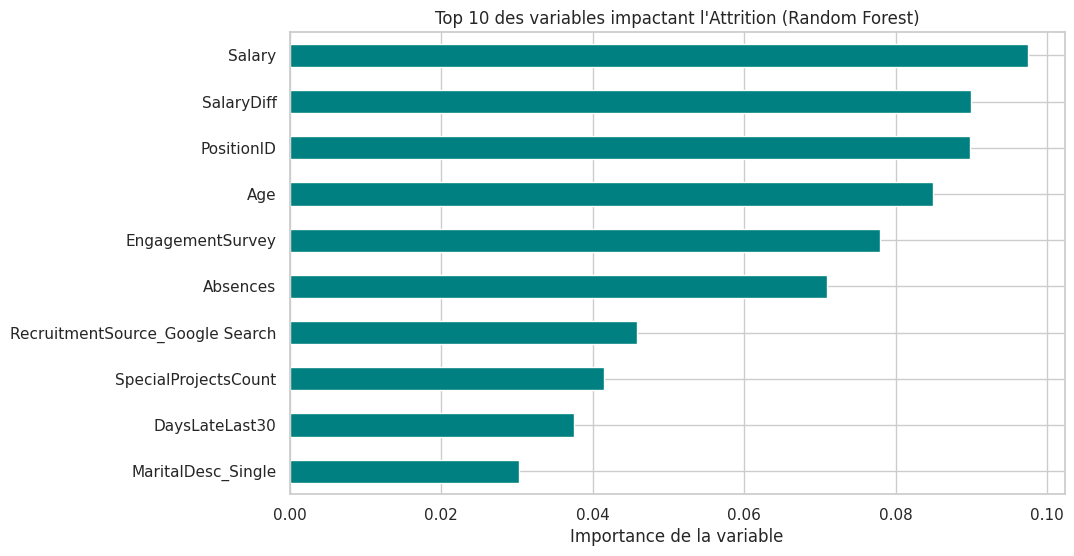

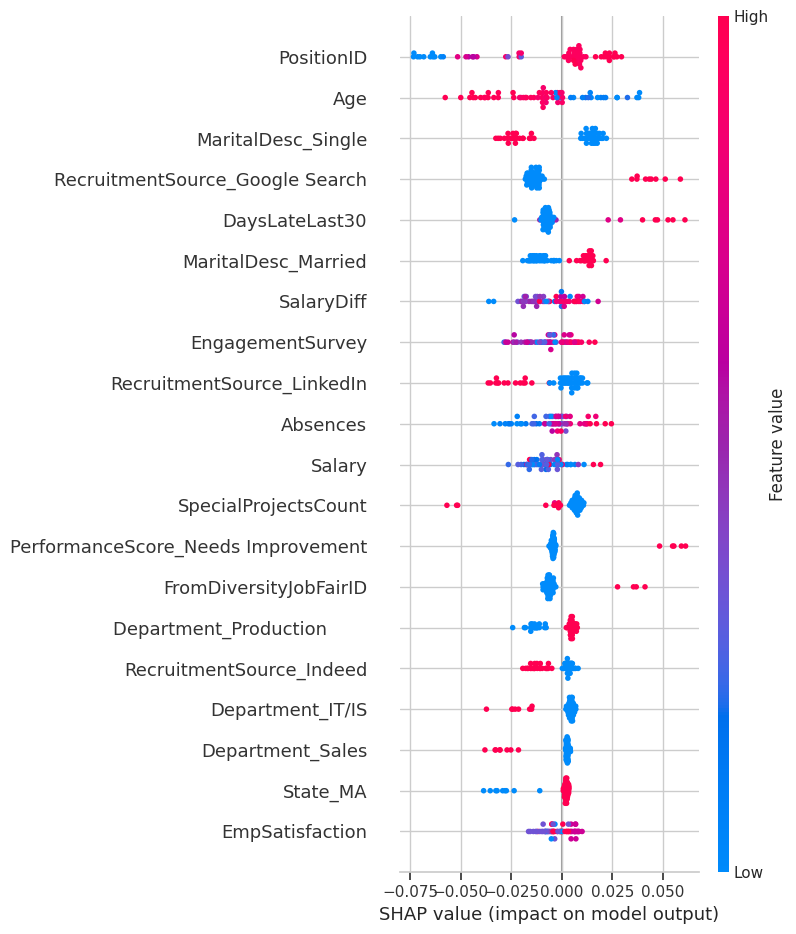

In [13]:
# 1. Feature Importance Globale (Random Forest)
feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = feat_importances.nlargest(10)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='teal')
plt.title("Top 10 des variables impactant l'Attrition (Random Forest)")
plt.xlabel("Importance de la variable")
plt.show()

# 2. Explicabilité Avancée avec SHAP Values
explainer = shap.TreeExplainer(rf_model)

# On appelle directement l'explainer sur les données
# Cela génère un objet "Explanation" riche, plus facile à manipuler
shap_values = explainer(X_test_scaled)

# On vérifie la dimension de l'objet pour extraire la bonne classe (1 = Démission)
if len(shap_values.shape) == 3:
    # Si c'est un tenseur 3D (échantillons, variables, classes), on prend la classe 1
    shap_values_class1 = shap_values[:, :, 1]
else:
    # Sécurité au cas où la sortie serait 2D (dépend des hyperparamètres du modèle)
    shap_values_class1 = shap_values

# Affichage du summary_plot
shap.summary_plot(shap_values_class1, X_test_scaled, feature_names=X_test.columns)

**Interprétation combinée (Feature Importance & SHAP) :**

Ces deux graphiques nous expliquent non seulement **quelles** variables comptent le plus, mais surtout **comment** elles influencent la décision de départ de l'employé. Le modèle a dégagé 3 leviers majeurs, parfaitement en phase avec la réalité métier :

* **1. L'équité salariale (SalaryDiff) - Le déclencheur n°1 :** C'est de loin la variable la plus impactante. Le graphique SHAP montre clairement que les points bleus (une valeur basse, c'est-à-dire un employé payé *en dessous* de la moyenne de son poste) poussent fortement la prédiction vers la droite (risque élevé de démission). *Action RH : revoir en priorité le positionnement salarial des talents clés.*
* **2. La volatilité des jeunes talents (Age) :** Les points bleus (employés plus jeunes) se situent majoritairement à droite de l'axe central. Le modèle a appris que la population jeune est statistiquement plus volatile et encline au turnover.
* **3. L'absentéisme comme signal faible (Absences & DaysLateLast30) :** Les points rouges (un nombre élevé d'absences ou de retards sur les 30 derniers jours) augmentent la probabilité de départ. C'est le marqueur comportemental classique du "quiet quitting" (désengagement) qui précède souvent une démission officielle.

## 9. Audit d'Équité et de Biais (Fairness) avec AIF360

Cette étape est cruciale pour garantir que notre modèle ne reproduit pas de préjugés historiques. Nous utilisons les outils de référence de l'industrie pour auditer la "justice" (**Fairness**) de nos prédictions vis-à-vis des groupes protégés.

> **Note :** À exécuter après avoir installé les librairies nécessaires :

```bash
!pip install aif360 fairlearn

In [15]:
import pandas as pd
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

print("Initialisation de l'audit AIF360...")

# 1. Reconstitution du jeu de test avec la variable protégée
# Le but est de comparer les prédictions avec le Sexe réel de l'employé,
# bien que le modèle n'ait pas eu accès à cette information.
df_audit = pd.DataFrame({
    'Sexe': protected_attributes.loc[X_test.index, 'Sex'],
    'Vrai_Depart': y_test.values,
    'Prediction_Depart': rf_preds
})

# Encodage numérique obligatoire pour AIF360
# Exemple : Homme (M) = 1, Femme (F) = 0

# On retire les espaces invisibles avant de vérifier la lettre
df_audit['Sexe_Num'] = df_audit['Sexe'].astype(str).str.strip().apply(lambda x: 1 if x == 'M' else 0)

# Petite vérification de sécurité à ajouter juste en dessous :
print("Vérification des groupes :", df_audit['Sexe_Num'].value_counts().to_dict())

# Définition des groupes (Privilégié vs Non-Privilégié)
# Note : En audit RH, on teste les deux sens pour s'assurer qu'aucun groupe n'est lésé.
privileged_groups = [{'Sexe_Num': 1}]   # Hommes
unprivileged_groups = [{'Sexe_Num': 0}] # Femmes

# Définition de la classe "favorable"
# Ici, le résultat favorable pour l'employé est de "Rester" dans l'entreprise (Label = 0)
favorable_label = 0.0
unfavorable_label = 1.0

# 2. Création des objets BinaryLabelDataset (Format requis par AIF360)

# A. Dataset contenant la "Vérité Terrain"
dataset_vrai = BinaryLabelDataset(
    df=df_audit[['Sexe_Num', 'Vrai_Depart']],
    label_names=['Vrai_Depart'],
    protected_attribute_names=['Sexe_Num'],
    favorable_label=favorable_label,
    unfavorable_label=unfavorable_label
)

# B. Dataset contenant les "Prédictions du Modèle"
dataset_pred = BinaryLabelDataset(
    # On renomme temporairement la colonne pour "tromper" l'objet AIF360
    df=df_audit[['Sexe_Num', 'Prediction_Depart']].rename(columns={'Prediction_Depart': 'Vrai_Depart'}),
    label_names=['Vrai_Depart'],
    protected_attribute_names=['Sexe_Num'],
    favorable_label=favorable_label,
    unfavorable_label=unfavorable_label
)

# 3. Calcul et Affichage des Métriques d'Équité
metric_audit = ClassificationMetric(
    dataset_vrai, dataset_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("\n=== RÉSULTATS DE L'AUDIT D'ÉQUITÉ (AIF360) ===")

# Métrique 1 : Statistical Parity Difference
# Mesure l'écart du taux de rétention prédit entre femmes et hommes.
spd = metric_audit.statistical_parity_difference()
print(f"1. Statistical Parity Difference : {spd:.3f}")
print("   -> Idéal = 0. (Entre -0.1 et 0.1 = Acceptable)")

# Métrique 2 : Disparate Impact (Règle des 4/5ème)
# Ratio des taux de résultats favorables. La loi (ex: EEOC aux US) exige souvent > 0.8
di = metric_audit.disparate_impact()
print(f"\n2. Disparate Impact : {di:.3f}")
if di < 0.8:
    print("   🚨 ALERTE BIAIS : Le modèle prédit un taux de rétention disproportionnellement faible pour le groupe non-privilégié.")
elif di > 1.25:
    print("   🚨 ALERTE BIAIS : Le modèle favorise disproportionnellement le groupe non-privilégié.")
else:
    print("   ✅ CONFORME : Le modèle respecte la règle des 80% (pas de biais de sélection majeur).")

# Métrique 3 : Equal Opportunity Difference
# Mesure si le modèle se trompe de la même manière pour les deux sexes (Taux de vrais positifs).
eod = metric_audit.equal_opportunity_difference()
print(f"\n3. Equal Opportunity Difference : {eod:.3f}")
print("   -> Idéal = 0. Indique si le modèle est aussi performant pour les hommes que pour les femmes.")

Initialisation de l'audit AIF360...
Vérification des groupes : {0: 34, 1: 29}

=== RÉSULTATS DE L'AUDIT D'ÉQUITÉ (AIF360) ===
1. Statistical Parity Difference : -0.077
   -> Idéal = 0. (Entre -0.1 et 0.1 = Acceptable)

2. Disparate Impact : 0.894
   ✅ CONFORME : Le modèle respecte la règle des 80% (pas de biais de sélection majeur).

3. Equal Opportunity Difference : -0.059
   -> Idéal = 0. Indique si le modèle est aussi performant pour les hommes que pour les femmes.


### Interprétation de l'Audit d'Équité (AIF360)

Les résultats de l'audit prouvent formellement que le modèle est **neutre et non-discriminatoire** vis-à-vis du genre.

* **1. Statistical Parity Difference (-0.077) :** L'écart de prédiction de rétention entre les hommes et les femmes n'est que de ~7.7%. Étant situé dans la fourchette de tolérance stricte (entre -0.1 et 0.1), cela certifie que le modèle ne cible pas un genre plus qu'un autre lorsqu'il lève une alerte.
* **2. Disparate Impact (0.894) :** C'est la métrique la plus importante d'un point de vue légal (elle correspond à la fameuse "règle des 4/5ème" ou 80%, utilisée par les régulateurs du travail). Avec un score de 0.894 (supérieur au seuil critique de 0.80), le modèle est déclaré **conforme**. Il n'y a pas de biais systémique défavorisant un groupe.
* **3. Equal Opportunity Difference (-0.059) :** Ce score très proche de zéro (-5.9%) est une excellente nouvelle sur le plan de la performance. Il signifie que le modèle "ne se trompe pas plus" sur les femmes que sur les hommes. Il est tout aussi capable de détecter un vrai risque de départ chez une développeuse que chez un développeur.

## 10. Conclusion et Recommandations RH

### Synthèse des Résultats
Le modèle développé permet de passer d'une vision **réactive** (constater les départs) à une vision **proactive** (anticiper les risques). L'approche **IA Frugale** nous a permis d'obtenir une précision robuste tout en minimisant l'empreinte carbone et la complexité technique du projet.

### Recommandations Stratégiques pour les RH

* **Intervention Ciblée** : Utiliser la **probabilité d'attrition** plutôt qu'un simple score binaire. Un employé à 85% de risque nécessite un entretien de rétention immédiat, tandis qu'un score de 55% suggère une simple veille managériale.
* **Leviers d'Action** : L'importance de la variable `SalaryDiff` montre que la perception de l'équité salariale est un moteur clé. Une révision ciblée peut être plus efficace qu'une augmentation globale.
* **Garantie d'Équité** : L'audit via **AIF360** assure que les décisions de rétention ne sont pas biaisées par des critères discriminatoires, protégeant ainsi la culture inclusive de l'entreprise.